# 02 · Differential expression: tumor vs normal

**Goal:** find genes that are significantly more (or less) active in liver tumors than in normal liver.

**Plan:** three DESeq2 runs.

| Run | Samples | Question it answers |
|---|---|---|
| **A · main** | all 371 tumors + 50 normals | Which genes differ between tumor and normal? |
| **B · paired** | 50 patients with both tumor and normal | Does the result hold when we compare tumor vs normal *inside the same person*? |
| **C · sensitivity** | run A without `TCGA-FV-A2QR-11A` | Did keeping that borderline normal sample change anything? |

Genes that are up in **both A and B** become our robust candidate list for survival (notebook 04) and druggability (notebook 05).

> ⏱ Each run takes a few minutes (roughly 5–15 min in total, depending on your computer). Results are cached in `results/`, so re-running the notebook later is instant.

In [1]:
import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import data

FIG = ROOT / "figures"
RES = ROOT / "results"
RES.mkdir(exist_ok=True)

N_CPUS = max(1, (os.cpu_count() or 2) - 1)   # leave one core free
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"Tumor": "#c0392b", "Normal": "#2e86c1"}

# significance thresholds, decided BEFORE looking at results
PADJ = 0.05      # false discovery rate 5%
LFC = 1.0        # at least 2x change (log2 fold change of 1)
print("CPUs used:", N_CPUS)

CPUs used: 11


## 1. Load the clean data from notebook 01

DESeq2 wants the table the other way around from notebook 01: **rows = samples, columns = genes**, so we flip it with `.T`.

In [2]:
counts = pd.read_csv(data.PROCESSED / "counts_filtered.csv.gz", index_col=0).T
meta = pd.read_csv(data.PROCESSED / "samples.csv", index_col=0)
gene_map = pd.read_csv(data.PROCESSED / "gene_map.csv", index_col=0).iloc[:, 0]

counts = counts.loc[meta.index]
print(f"{counts.shape[0]} samples x {counts.shape[1]:,} genes")
print(meta["condition"].value_counts())

421 samples x 22,107 genes
condition
Tumor     371
Normal     50
Name: count, dtype: int64


## 2. A helper that runs DESeq2

What DESeq2 does, in short:
1. **Normalizes** for library size (the "more pixels" problem from notebook 01)
2. **Estimates noise** for every gene (how much it naturally varies between people)
3. **Tests** each gene: is the tumor–normal difference bigger than the noise?
4. **Corrects p-values** for testing 22,000 genes at once → `padj`

We also **shrink** fold changes: genes with few reads can show huge but unreliable fold changes, and shrinkage pulls those toward zero. We keep both versions.

In [3]:
def run_deseq(counts, meta, design, name, force=False):
    """Run DESeq2 (Tumor vs Normal) and cache results to results/de_<name>.csv.gz."""
    out = RES / f"de_{name}.csv.gz"
    if out.exists() and not force:
        print(f"Loaded cached results: {out.name}")
        return pd.read_csv(out, index_col=0)

    inference = DefaultInference(n_cpus=N_CPUS)
    dds = DeseqDataSet(counts=counts, metadata=meta, design=design,
                       refit_cooks=True, inference=inference, quiet=True)
    dds.deseq2()

    coeff = [c for c in dds.varm["LFC"].columns if c.startswith("condition")]
    assert coeff == ["condition[T.Tumor]"], f"Unexpected reference level: {coeff}"

    ds = DeseqStats(dds, contrast=["condition", "Tumor", "Normal"],
                    alpha=PADJ, inference=inference, quiet=True)
    ds.summary()
    res = ds.results_df.copy()
    res = res.rename(columns={"log2FoldChange": "log2FC_raw"})

    ds.lfc_shrink(coeff=coeff[0])                     # overwrites log2FoldChange with shrunk values
    res["log2FC"] = ds.results_df["log2FoldChange"]

    res.insert(0, "gene", gene_map.reindex(res.index).values)
    res = res.sort_values("padj")
    res.to_csv(out)
    print(f"Saved {out.name}")
    return res


def significant(res, direction="up"):
    sig = res["padj"] < PADJ
    return res[sig & (res["log2FC"] > LFC)] if direction == "up" else res[sig & (res["log2FC"] < -LFC)]

## 3. Run A · all samples (main analysis)

Design `~condition`: the only thing we tell DESeq2 is whether a sample is tumor or normal. `Normal` is the reference, so **positive log2FC = higher in tumor**.

In [4]:
%%time
res_all = run_deseq(counts, meta, "~condition", "all_samples")

up_A, down_A = significant(res_all, "up"), significant(res_all, "down")
print(f"Up in tumor:   {len(up_A):,}")
print(f"Down in tumor: {len(down_A):,}")
res_all.head(10).round(3)

Fitting dispersions...
... done in 0.72 seconds.

Fitting MAP dispersions...
... done in 0.69 seconds.

Fitting LFCs...
... done in 0.75 seconds.



Saved de_all_samples.csv.gz
Up in tumor:   4,496
Down in tumor: 1,307
CPU times: total: 23.3 s
Wall time: 44.5 s


,gene,baseMean,log2FC_raw,lfcSE,stat,pvalue,padj,log2FC
gene_id,,,,,,,,
ENSG00000187730.9,GABRD,165.249,4.453,0.194,22.964,0.0,0.0,4.438
ENSG00000130300.9,PLVAP,4376.180,2.901,0.138,20.986,0.0,0.0,2.890
ENSG00000100526.20,CDKN3,366.211,3.904,0.189,20.608,0.0,0.0,3.887
ENSG00000158402.20,CDC25C,193.719,4.349,0.213,20.393,0.0,0.0,4.330
ENSG00000077152.11,UBE2T,367.604,3.195,0.157,20.325,0.0,0.0,3.179
ENSG00000143228.13,NUF2,268.565,4.190,0.207,20.201,0.0,0.0,4.172
ENSG00000117724.13,CENPF,982.137,3.878,0.192,20.168,0.0,0.0,3.861
ENSG00000154839.10,SKA1,219.023,4.461,0.222,20.134,0.0,0.0,4.441
ENSG00000043355.12,ZIC2,232.506,6.665,0.333,19.995,0.0,0.0,6.633


## 4. Volcano plot

- **x-axis:** how big the change is (log2FC). Right = higher in tumor, left = lower.
- **y-axis:** how confident we are (−log10 padj). Higher = more certain.
- Top-right and top-left corners = big changes we're confident about.

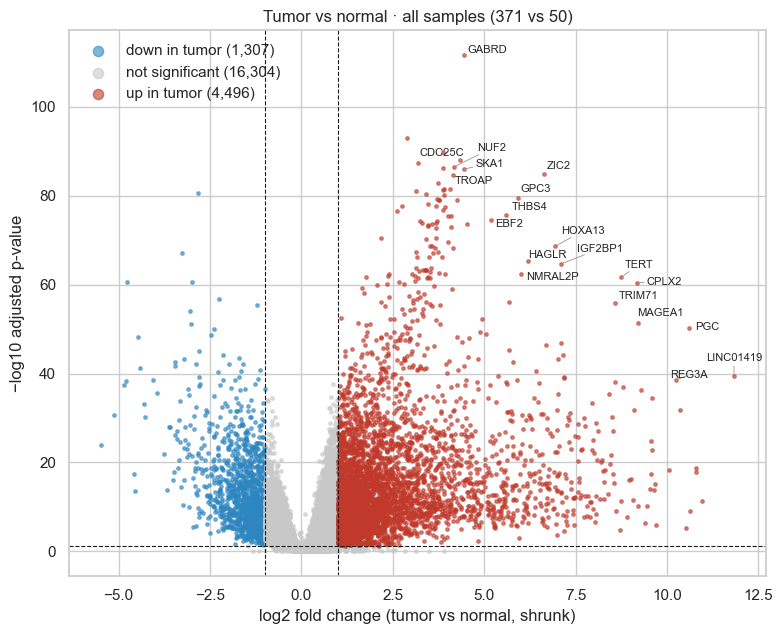

In [5]:
def volcano(res, title, fname, n_labels=20):
    df = res.dropna(subset=["padj"]).copy()
    df["neglog10"] = -np.log10(df["padj"].clip(lower=1e-300))
    df["status"] = "not significant"
    df.loc[(df["padj"] < PADJ) & (df["log2FC"] > LFC), "status"] = "up in tumor"
    df.loc[(df["padj"] < PADJ) & (df["log2FC"] < -LFC), "status"] = "down in tumor"
    colors = {"up in tumor": "#c0392b", "down in tumor": "#2e86c1", "not significant": "#c8c8c8"}

    fig, ax = plt.subplots(figsize=(8, 6.5))
    for status, sub in df.groupby("status"):
        ax.scatter(sub["log2FC"], sub["neglog10"], s=6, alpha=.6, c=colors[status],
                   label=f"{status} ({len(sub):,})", rasterized=True)
    ax.axhline(-np.log10(PADJ), ls="--", lw=.8, c="k")
    ax.axvline(LFC, ls="--", lw=.8, c="k"); ax.axvline(-LFC, ls="--", lw=.8, c="k")

    sig = df[df["status"] != "not significant"].copy()
    sig["score"] = sig["log2FC"].abs() * sig["neglog10"]
    top = sig.nlargest(n_labels, "score")
    texts = [ax.text(r["log2FC"], r["neglog10"], r["gene"], fontsize=8) for _, r in top.iterrows()]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="grey", lw=.5))

    ax.set(xlabel="log2 fold change (tumor vs normal, shrunk)", ylabel="−log10 adjusted p-value", title=title)
    ax.legend(frameon=False, loc="upper left", markerscale=3)
    plt.tight_layout(); plt.savefig(FIG / fname, dpi=150); plt.show()

volcano(res_all, "Tumor vs normal · all samples (371 vs 50)", "02_volcano.png")

## 5. Run B · paired patients

Design `~patient + condition`: DESeq2 first accounts for **who the sample came from**, then tests tumor vs normal. Differences between people (age, genetics, liver disease) cancel out.

It has fewer samples (50 vs 50), so it will find fewer genes. What matters is whether it **agrees** with run A.

In [6]:
%%time
paired = meta[meta["paired"]]
res_paired = run_deseq(counts.loc[paired.index], paired, "~patient + condition", "paired")

up_B = significant(res_paired, "up")
print(f"Up in tumor (paired): {len(up_B):,}")

Saved de_paired.csv.gz
Up in tumor (paired): 1,859
CPU times: total: 19.9 s
Wall time: 58.5 s


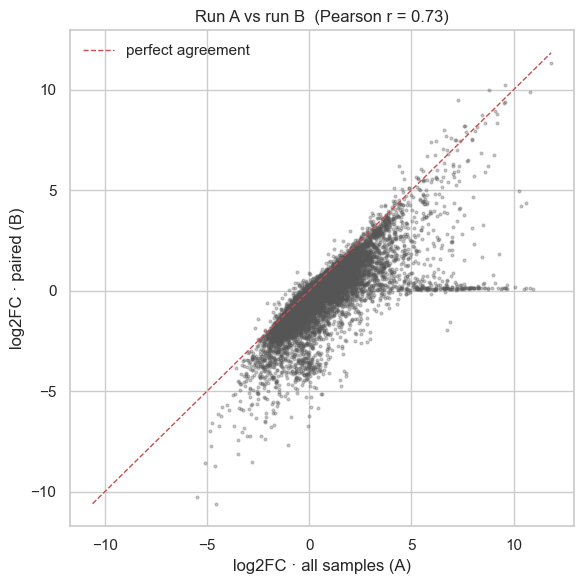

Up in A: 4,496 | up in B: 1,859 | up in BOTH: 1,842 (41% of A)
Down in both: 1,261


In [7]:
both = res_all[["gene", "log2FC"]].join(res_paired[["log2FC"]], rsuffix="_paired", how="inner").dropna()
r = both["log2FC"].corr(both["log2FC_paired"])

robust_up = up_A.index.intersection(up_B.index)
robust_down = down_A.index.intersection(significant(res_paired, "down").index)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(both["log2FC"], both["log2FC_paired"], s=4, alpha=.3, c="#555", rasterized=True)
lim = [both.min(numeric_only=True).min(), both.max(numeric_only=True).max()]
ax.plot(lim, lim, "r--", lw=1, label="perfect agreement")
ax.set(xlabel="log2FC · all samples (A)", ylabel="log2FC · paired (B)",
       title=f"Run A vs run B  (Pearson r = {r:.2f})")
ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(FIG / "02_all_vs_paired.png", dpi=150); plt.show()

print(f"Up in A: {len(up_A):,} | up in B: {len(up_B):,} | up in BOTH: {len(robust_up):,} "
      f"({len(robust_up) / len(up_A):.0%} of A)")
print(f"Down in both: {len(robust_down):,}")

## 6. Run C · sensitivity check

In notebook 01 we kept the borderline normal sample `TCGA-FV-A2QR-11A`. Here we rerun the main analysis **without it**. If the results barely change, keeping it was fine.

In [8]:
%%time
SUSPECT = "TCGA-FV-A2QR-11A"
if SUSPECT in meta.index:
    keep = meta.index.drop(SUSPECT)
    res_sens = run_deseq(counts.loc[keep], meta.loc[keep], "~condition", "sensitivity_no_FV-A2QR")

    cmp = res_all[["log2FC"]].join(res_sens[["log2FC"]], rsuffix="_without", how="inner").dropna()
    r_sens = cmp["log2FC"].corr(cmp["log2FC_without"])
    up_C = significant(res_sens, "up")
    top_A = set(up_A.nsmallest(200, "padj").index)
    top_C = set(up_C.nsmallest(200, "padj").index)

    print(f"log2FC correlation with vs without the sample: r = {r_sens:.4f}")
    print(f"Up in tumor: {len(up_A):,} (with) vs {len(up_C):,} (without)")
    print(f"Overlap of top 200 upregulated genes: {len(top_A & top_C)} / 200")
else:
    print(f"{SUSPECT} not in data (maybe dropped in notebook 01) — skipping.")

Fitting dispersions...
... done in 0.75 seconds.

Fitting MAP dispersions...
... done in 0.71 seconds.

Fitting LFCs...
... done in 0.80 seconds.



Saved de_sensitivity_no_FV-A2QR.csv.gz
log2FC correlation with vs without the sample: r = 0.9995
Up in tumor: 4,496 (with) vs 4,516 (without)
Overlap of top 200 upregulated genes: 196 / 200
CPU times: total: 21.9 s
Wall time: 39.1 s


## 7. Heatmap of the top genes

Top 25 robust up + top 25 robust down genes (biggest fold change).

- Values are **z-scores** of normalized expression per gene: red = higher than that gene's average, blue = lower.
- Columns are samples (normals first, then tumors), rows are genes.

c:\Users\KORISNIK\Downloads\liver-cancer-target-discovery\liver-cancer-target-discovery\.venv\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


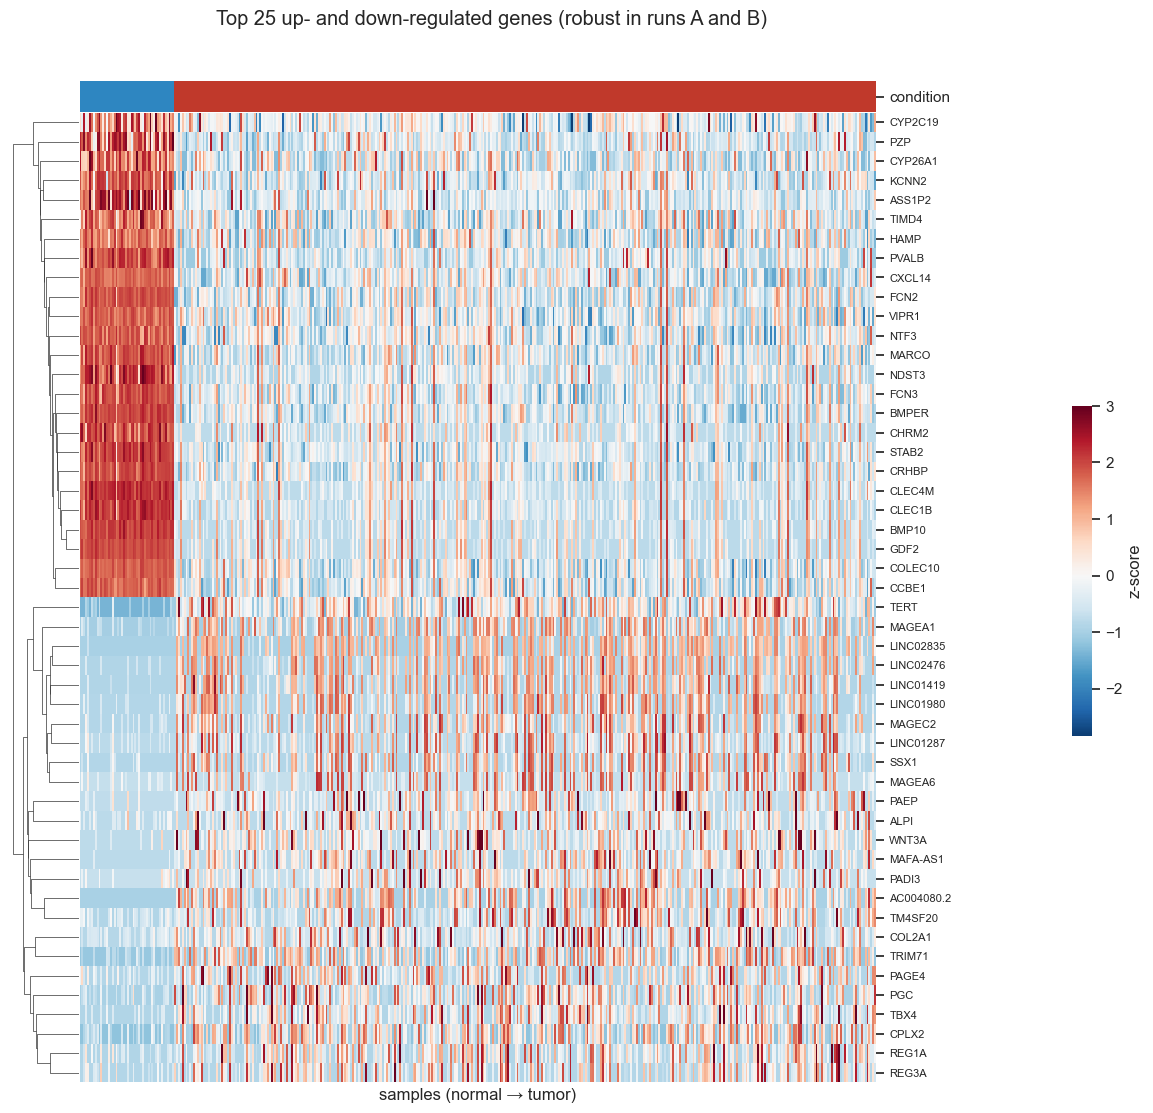

In [9]:
def median_of_ratios(counts):
    """DESeq2-style normalization: divide each sample by its size factor."""
    log_c = np.log(counts.replace(0, np.nan))
    log_geo_mean = log_c.mean(axis=0)                       # per gene, ignoring zeros
    usable = log_c.columns[log_c.notna().all(axis=0)]      # genes with no zeros anywhere
    size_factors = np.exp((log_c[usable] - log_geo_mean[usable]).median(axis=1))
    return counts.div(size_factors, axis=0)

norm_log = np.log2(median_of_ratios(counts) + 1)

top_up = res_all.loc[robust_up].nlargest(25, "log2FC").index
top_down = res_all.loc[robust_down].nsmallest(25, "log2FC").index
genes = top_up.append(top_down)

order = meta.sort_values("condition").index                # Normal first, then Tumor
mat = norm_log.loc[order, genes].T
mat = mat.sub(mat.mean(axis=1), axis=0).div(mat.std(axis=1), axis=0).clip(-3, 3)
mat.index = gene_map.reindex(mat.index).fillna(pd.Series(mat.index, index=mat.index)).values

g = sns.clustermap(mat, col_cluster=False, row_cluster=True, cmap="RdBu_r", center=0,
                   col_colors=meta.loc[order, "condition"].map(PALETTE).rename("condition"),
                   xticklabels=False, yticklabels=True, figsize=(10, 11),
                   cbar_kws={"label": "z-score"}, dendrogram_ratio=(.08, .04),
                   cbar_pos=(1.08, .35, .02, .3))
g.ax_heatmap.set(xlabel="samples (normal → tumor)", ylabel="")
g.ax_heatmap.tick_params(axis="y", labelsize=8)
g.figure.suptitle("Top 25 up- and down-regulated genes (robust in runs A and B)", y=1.01)
plt.savefig(FIG / "02_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

## 8. Candidate list for the next notebooks

**Robust upregulated genes** = significantly up in run A **and** run B. These go on to survival analysis. We focus on *up* genes because a drug usually works by **blocking** something the tumor has too much of.

In [10]:
candidates = (res_all.loc[robust_up, ["gene", "baseMean", "log2FC", "padj"]]
              .join(res_paired[["log2FC", "padj"]], rsuffix="_paired")
              .sort_values("log2FC", ascending=False))
candidates.to_csv(RES / "de_upregulated_robust.csv")

summary = pd.DataFrame({
    "run": ["A · all samples", "B · paired", "robust (A and B)"],
    "up in tumor": [len(up_A), len(up_B), len(robust_up)],
    "down in tumor": [len(down_A), len(significant(res_paired, "down")), len(robust_down)],
})
summary.to_csv(RES / "de_summary.csv", index=False)

print(f"Saved {len(candidates):,} robust upregulated genes → results/de_upregulated_robust.csv")
display(summary)
candidates.head(25).round(3)

Saved 1,842 robust upregulated genes → results/de_upregulated_robust.csv


,run,up in tumor,down in tumor
0,A · all samples,4496,1307
1,B · paired,1859,2872
2,robust (A and B),1842,1261


,gene,baseMean,log2FC,padj,log2FC_paired,padj_paired
gene_id,,,,,,
ENSG00000253898.1,LINC01419,380.134,11.832,0.0,11.314,0.000
ENSG00000253508.1,AC004080.2,11.805,10.786,0.0,9.907,0.000
ENSG00000096088.16,PGC,1292.062,10.613,0.0,4.375,0.000
ENSG00000115386.6,REG1A,996.752,10.346,0.0,4.220,0.000
ENSG00000172016.16,REG3A,4113.990,10.246,0.0,4.938,0.000
ENSG00000285711.1,LINC02835,23.193,9.591,0.0,10.244,0.000
ENSG00000122133.17,PAEP,124.280,9.553,0.0,9.318,0.005
ENSG00000139219.19,COL2A1,340.664,9.302,0.0,1.836,0.000
ENSG00000198681.7,MAGEA1,365.029,9.207,0.0,8.790,0.000


## Notes

- **Run A (all samples):** 4,496 genes up, 1,307 down in tumor (padj < 0.05, |log2FC| > 1)
- **Run B (paired):** 1,859 up, 2,872 down
- **Robust (A and B):** 1,842 up (41% of A, but 99% of B), 1,261 down
  - A finds more up genes because 371 tumors give power to detect genes up in only a subset of tumors; B (50 pairs) mainly detects genes up in most patients.
- **Correlation A vs B:** r = 0.73
  - Horizontal streak in the scatter: genes very high in a few tumors (log2FC 5–11 in A) are shrunk to ~0 in the paired run due to insufficient evidence. These are excluded from the robust list.
  - B's fold changes are slightly shifted downward overall (likely different normalization with 100 vs 421 samples), consistent with B finding fewer up and more down genes. Direction of change agrees for the main cloud of genes.
- **Sensitivity (without TCGA-FV-A2QR-11A):** r = 0.9995, top-200 overlap 196 / 200, up genes 4,496 vs 4,516 → keeping the sample did not change the results.
- **Top genes:** the most significant genes are cell-cycle/proliferation genes (CDKN3, CDC25C, UBE2T, NUF2, CENPF, SKA1, TROAP). Known HCC genes recovered: GPC3, TERT, IGF2BP1, HOXA13, REG3A (HIP/PAP), PLVAP, MAGEA1.
- **Surprising / to follow up:** top genes by fold change (LINC01419, AC004080.2, PGC, REG1A, REG3A) include non-coding RNAs, which are not druggable, and genes that are extremely high in only a subset of tumors (much smaller fold change in the paired run). For target selection, also check the % of tumors in which a gene is above normal levels, not just fold change.